In [227]:
#import libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots



In [228]:
# read the cleaned dataset
df = pd.read_csv('../data/processed/retail_sales_dataset_cleaned.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_id    1000 non-null   int64 
 1   date              1000 non-null   object
 2   customer_id       1000 non-null   object
 3   gender            1000 non-null   object
 4   age               1000 non-null   int64 
 5   product_category  1000 non-null   object
 6   quantity          1000 non-null   int64 
 7   price_per_unit    1000 non-null   int64 
 8   total_amount      1000 non-null   int64 
 9   year              1000 non-null   int64 
 10  month             1000 non-null   int64 
 11  month_name        1000 non-null   object
 12  weekday           1000 non-null   object
 13  age_group         1000 non-null   object
 14  age_category      1000 non-null   int64 
dtypes: int64(8), object(7)
memory usage: 117.3+ KB


In [229]:
# Create a pivot table to analyze the relationship between age groups and product categories for all customers
agegrp_pivot = pd.pivot_table(df, 
    index='age_group', 
    columns='product_category',
          values='quantity', aggfunc='count', observed=True).fillna(0).reset_index() #count to show the no. of customers
agegrp_pivot

product_category,age_group,Beauty,Clothing,Electronics
0,18-24,53,45,51
1,25-34,68,73,62
2,35-44,51,79,77
3,45-54,73,74,78
4,55-64,62,80,74


In [230]:
# Create a stacked bar chart to visualize the quantity of products sold by age group and product category
graph = go.Figure()

#bar graph customers purchasing beauty products
graph.add_trace(
    go.Bar(
        name= 'Beauty',
        x= agegrp_pivot['age_group'], 
        y= agegrp_pivot['Beauty'],
        marker_color= 'pink', 
    )
)

#bar graph customers purchasing clothing
graph.add_trace(
    go.Bar(
        name= 'Clothing',
        x= agegrp_pivot['age_group'], 
        y= agegrp_pivot['Clothing'],
        marker_color= 'lightblue', 
    )
)

#bar graph customers purchasing electronics
graph.add_trace(
    go.Bar(
        name= 'Electronics',
        x= agegrp_pivot['age_group'],
        y= agegrp_pivot['Electronics'],
        marker_color= 'indigo', 
    )
)

#update layout 
graph.update_layout(
    title= 'Number of Customers Purchasing Products by Age Group',
    xaxis_title= 'Age Group',
    yaxis_title= 'No. of Customers',
    barmode= 'stack' #each catergory is stacked in one bar
)
graph.show()

In [231]:
# Create a pivot table to analyze the relationship between age groups and product categories for all customers
agegrp_month_pivot = pd.pivot_table(df, 
    index=['month','month_name'],   #month and month name was index to keep the order correct
    columns='product_category',
          values='quantity', aggfunc='count', observed=True).fillna(0).reset_index() #count to show the no. of customers
agegrp_month_pivot

product_category,month,month_name,Beauty,Clothing,Electronics
0,1,Jan,26,26,26
1,2,Feb,26,33,26
2,3,Mar,21,38,14
3,4,Apr,29,36,21
4,5,May,28,37,40
5,6,Jun,25,28,24
6,7,Jul,27,19,26
7,8,Aug,24,32,38
8,9,Sep,20,20,25
9,10,Oct,31,30,35


In [240]:
# Create a line graph  to visualize the number of customer purchasing in each category by month
graph = go.Figure()

#line graph customers purchasing beauty products
graph.add_trace(
    go.Scatter(
        name= 'Beauty',
        x= agegrp_month_pivot['month_name'], 
        y= agegrp_month_pivot['Beauty'],
        marker_color= 'pink', 
    )
)

#line graph customers purchasing clothing
graph.add_trace(
    go.Scatter(
        name= 'Clothing',
        x= agegrp_month_pivot['month_name'], 
        y= agegrp_month_pivot['Clothing'],
        marker_color= 'lightblue', 
    )
)

#line graph customers purchasing electronics 
graph.add_trace(
    go.Scatter(
        name= 'Electronics',
        x= agegrp_month_pivot['month_name'],
        y= agegrp_month_pivot['Electronics'],
        marker_color= 'indigo',
    )
)

graph.update_layout(
    title= 'Number of Customers in a Year',
    xaxis_title= 'Month',
    yaxis_title= 'Number of Customers',
    barmode= 'stack',
    plot_bgcolor= 'white'
)
graph.show()

In [233]:
# Create a pivot table to analyze the relationship product categories and number of Male customers
df_male = df[df['gender'] == 'Male']

male_month_pivot = pd.pivot_table(df_male, 
    index=['month', 'month_name'],  #month and month name was index to keep the order correct
    columns='product_category',
          values='quantity', aggfunc='count', observed=True).fillna(0).reset_index()
male_month_pivot, female_month_pivot

# Create a pivot table to analyze the relationship between age groups and number of Female customers
df_female = df[df['gender'] == 'Female']

female_month_pivot = pd.pivot_table(df_female, 
    index=['month', 'month_name'], 
    columns='product_category',
          values='quantity', aggfunc='count', observed=True).fillna(0).reset_index()
female_month_pivot




product_category,month,month_name,Beauty,Clothing,Electronics
0,1,Jan,16,11,13
1,2,Feb,12,12,12
2,3,Mar,14,18,9
3,4,Apr,19,22,9
4,5,May,16,15,14
5,6,Jun,11,16,12
6,7,Jul,13,12,12
7,8,Aug,12,14,24
8,9,Sep,9,12,14
9,10,Oct,14,13,16


In [234]:
# Create a line graph to visualize the number of customers purchasing the number of products

#create subplots to show Male and Female customer trends in separate graphs 
graph = make_subplots(
    rows=1, cols=2,         #no. row and coloumn to show graph 
    subplot_titles=('Male Customers', 'Female Customers'),  #subtitle for each graph
    shared_yaxes=True)      #shared y-axis 

#set the marker and line size
marker_style =dict(
    mode='lines+markers',
    line=dict(width=3),
        marker=dict(size=3,
        symbol='circle',
        line=dict(width=3)
        )
    )

#set colour for each catergory 
color = {'Beauty': {'line': '#bc103b', 'marker': '#bc103b'},
         'Clothing': {'line': '#4f88f3', 'marker': '#4f88f3'},
         'Electronics': {'line': '#d5b8b4', 'marker': '#d5b8b4'}
         }

#line graph for male customers purchasing beauty products
graph.add_trace(
    go.Scatter(
        name= 'Beauty',
        x= male_month_pivot['month_name'], 
        y= male_month_pivot['Beauty'],
        marker_color= color['Beauty']['marker'],
        line_color=color['Beauty']['line'],
       **marker_style,
    ),
    row=1, col=1
)

#line graph for male customers purchasing clothing 
graph.add_trace(
    go.Scatter(
        name= 'Clothing',
        x= male_month_pivot['month_name'], 
        y= male_month_pivot['Clothing'],
         marker_color= color['Clothing']['marker'],
        line_color=color['Clothing']['line'], 
         **marker_style,
    ),
    row=1, col=1
)

#line graph for male customers purchasing electronics
graph.add_trace(
    go.Scatter(
        name= 'Electronics',
        x= male_month_pivot['month_name'],
        y= male_month_pivot['Electronics'],
        marker_color= color['Electronics']['marker'],
        line_color=color['Electronics']['line'], 
         **marker_style,
    ),
    row=1, col=1
)

#line graph for female customers purchasing beauty products
graph.add_trace(
    go.Scatter(
        name= 'Beauty',
        x= female_month_pivot['month_name'], 
        y= female_month_pivot['Beauty'],
        marker_color= color['Beauty']['marker'],
        line_color=color['Beauty']['line'],
         **marker_style,
        showlegend=False #not show legend for second graph
    ), 
    row=1, col=2
)

#line graph for female customers purchasing clothing 
graph.add_trace(
    go.Scatter(
        name= 'Clothing',
        x= female_month_pivot['month_name'], 
        y= female_month_pivot['Clothing'],
        marker_color= color['Clothing']['marker'],
        line_color=color['Clothing']['line'],
        **marker_style,
        showlegend=False,
    ),
    row=1, col=2
)

#line graph for female customers purchasing electronics
graph.add_trace(
    go.Scatter(
        name= 'Electronics',
        x= female_month_pivot['month_name'],
        y= female_month_pivot['Electronics'],
        marker_color= color['Electronics']['marker'],
        line_color=color['Electronics']['line'], 
         **marker_style,
        showlegend=False,
    ),
    row=1, col=2
)

#update layout 
graph.update_layout(
    title= '<b>Yearly Purchase Volume by Product Category</b>',  #bold title
    title_x=0.5,                                                 
    title_xanchor= 'center',                                      
    xaxis_title= 'Month',       #x-axis title for first graph
    xaxis2_title= 'Month',      #x-axis title for second graph
    yaxis_title= 'No. of Customers',  #y-axis title for first graph
    plot_bgcolor= 'white',              #update background color to white
)

#update grid lines for x axis
graph.update_xaxes(showgrid=True, gridcolor='lightgrey',
                   showline=True, linecolor='black',
                   )

#update gird lines for y-axis
graph.update_yaxes(showgrid=True, gridcolor='lightgrey',
                   showline=True, linecolor='black')

graph.show()

In [235]:
# Create a pivot table to analyze the relationship between age groups and product categories for Male customers
df_male = df[df['gender'] == 'Male']

male_agegrp_pivot = pd.pivot_table(df_male, 
    index='age_group', 
    columns='product_category',
          values='quantity', aggfunc='count', observed=True).fillna(0).reset_index() #count to show the no. of customers
male_agegrp_pivot, female_agegrp_pivot

# Create a pivot table to analyze the relationship between age groups and product categories for Female cusotmers only
df_female = df[df['gender'] == 'Female']

female_agegrp_pivot = pd.pivot_table(df_female, 
    index='age_group', 
    columns='product_category',
          values='quantity', aggfunc='count', observed=True).fillna(0).reset_index() #count to show the no. of customers
female_agegrp_pivot
# Create a line graph to visualize the number of customers purchasing the number of products



product_category,age_group,Beauty,Clothing,Electronics
0,18-24,29,16,27
1,25-34,36,33,33
2,35-44,28,43,41
3,45-54,39,40,36
4,55-64,34,42,33


In [236]:
# Create a bar graph to visualize the number of customers in each age-group purchaing in each product category 

#create subplots to show Male and Female customer trends in separate graphs 
graph = make_subplots(
    rows=1, cols=2, 
    subplot_titles=('Male Customers', 'Female Customers'),
    shared_yaxes=True) #does add separte axis for second graph

#create color dictionary 
color = {'Beauty': {'line': '#bc103b', 'marker': '#bc103b'},
         'Clothing': {'line': '#4f88f3', 'marker': '#4f88f3'},
         'Electronics': {'line': '#d5b8b4', 'marker': '#d5b8b4'}
         }

#bar graph for male customers purchasing beauty products
graph.add_trace(
    go.Bar(
        name= 'Beauty',
        x= male_agegrp_pivot['age_group'], 
        y= male_agegrp_pivot['Beauty'],
        marker_color= color['Beauty']['marker'],
        marker_line_color=color['Beauty']['line'], 
    ),
    row=1, col=1
)

#bar graph for male customers purchasing clothing
graph.add_trace(
    go.Bar(
        name= 'Clothing',
        x= male_agegrp_pivot['age_group'], 
        y= male_agegrp_pivot['Clothing'],
        marker_color= color['Clothing']['marker'],
        marker_line_color=color['Clothing']['line'], 
    ),
    row=1, col=1
)

#bar graph for male customers purchasing electronics 
graph.add_trace(
    go.Bar(
        name= 'Electronics',
        x= male_agegrp_pivot['age_group'],
        y= male_agegrp_pivot['Electronics'],
        marker_color= color['Electronics']['marker'],
        marker_line_color=color['Electronics']['line'], 
    ),
    row=1, col=1
)

#bar graph for female customers purchasing beauty products
graph.add_trace(
    go.Bar(
        name= 'Beauty',
        x= female_agegrp_pivot['age_group'], 
        y= female_agegrp_pivot['Beauty'],
        marker_color= color['Beauty']['marker'],
        marker_line_color=color['Beauty']['line'], 
        showlegend=False
    ), 
    row=1, col=2
)

#bar graph for female customers purchasing clothing
graph.add_trace(
    go.Bar(
        name= 'Clothing',
        x= female_agegrp_pivot['age_group'], 
        y= female_agegrp_pivot['Clothing'],
        marker_color= color['Clothing']['marker'],
        marker_line_color=color['Clothing']['line'], 
        showlegend=False,
    ),
    row=1, col=2
)

#bar graph for male customers purchasing electronics 
graph.add_trace(
    go.Bar(
        name= 'Electronics',
        x= female_agegrp_pivot['age_group'],
        y= female_agegrp_pivot['Electronics'],
        marker_color= color['Electronics']['marker'],
        marker_line_color=color['Electronics']['line'], 
        showlegend=False,
    ),
    row=1, col=2
)

#update graph layout
graph.update_layout(
    title= '<b>Purchasing Trends by Product Category and Age Group</b>',
    title_x=0.5,
    title_xanchor= 'center',
    xaxis_title= 'Age Group',
    xaxis2_title= 'Age Group',
    yaxis_title= 'No. of Customers',
    barmode= 'group',   #group the bar chart
    plot_bgcolor= 'white',
    
)

#update gird lines for x-axis
graph.update_xaxes(showgrid=True, gridcolor='lightgrey',
                   showline=True, linecolor='black',
                   )

#update gird lines for x-axis
graph.update_yaxes(showgrid=True, gridcolor='lightgrey',
                   showline=True, linecolor='black')

graph.show()

In [238]:
# Create a pivot table to analyze the relationship between product categories and months
monthly_sales = df.groupby(['product_category', 'month', 'month_name'])['quantity'].sum().reset_index()
pivot_monthly_sales = monthly_sales.pivot(index=['month', 'month_name'], columns='product_category', values='quantity').fillna(0).reset_index()
pivot_monthly_sales

product_category,month,month_name,Beauty,Clothing,Electronics
0,1,Jan,62,72,65
1,2,Feb,68,75,71
2,3,Mar,51,111,32
3,4,Apr,69,93,52
4,5,May,65,97,97
5,6,Jun,66,67,64
6,7,Jul,70,45,61
7,8,Aug,62,78,87
8,9,Sep,50,60,60
9,10,Oct,83,74,95


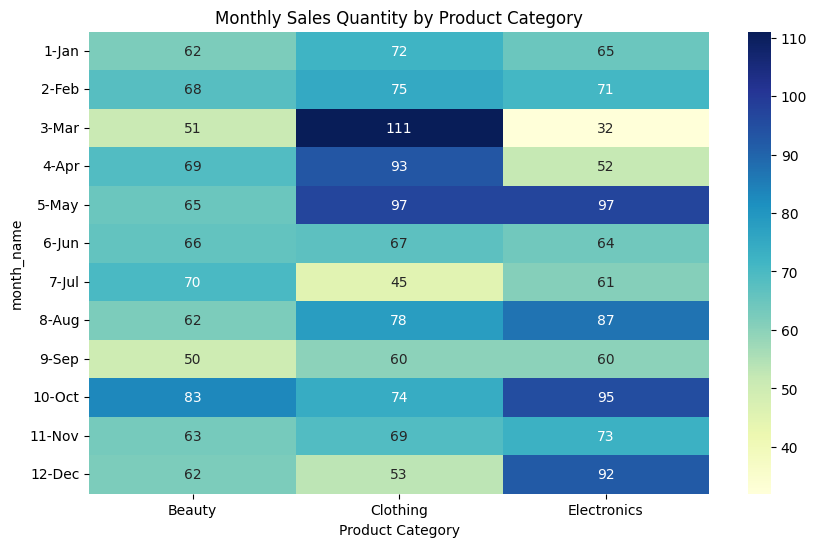

In [ ]:
# Create a heatmap to visualize the quantity of products sold by month and product category
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_monthly_sales.set_index(['month', 'month_name']), annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Monthly Sales Quantity by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Month')
plt.show()

Data Visualization

Data visualization was used to explore patterns in customer purchasing behavior and communicate insights clearly. The charts were created using Python libraries such as Matplotlib, Seaborn, and Plotly, with attention to readability and accessible color choices.

One key visualization is a stacked bar chart showing the number of customers purchasing products by age group and product category (Electronics, Clothing, Beauty). The chart compares five age groups: 18–24, 25–34, 35–44, 45–54, and 55–64, allowing both total purchases and category distribution to be viewed simultaneously.

The visualization highlights several trends:

Customers aged 45–54 show the highest overall purchasing activity.

The 18–24 group has the lowest purchase counts.

Clothing purchases remain relatively consistent across age groups.

Electronics purchases increase among middle-age customers.

Overall, the visualizations help reveal demographic purchasing patterns and category preferences, supporting better understanding of customer behavior in the retail dataset.